# Piecewise Constant Cox PH: Bayesian vs Frequentist

This notebook compares two implementations of the Cox Proportional Hazards model:

| | **Frequentist** | **Bayesian** |
|---|---|---|
| **Implementation** | `lifelines.CoxPHFitter` | `bayes_survival.PiecewiseCoxPHModel` |
| **Estimation** | Cox partial likelihood (MLE) | Poisson likelihood (MCMC) |
| **Baseline hazard** | Nelson–Aalen / Breslow (post-hoc) | Piecewise constant, jointly estimated |
| **Uncertainty** | Asymptotic 95% CI | Exact 95% HDI |
| **Baseline prior** | None | Gaussian Random Walk on $\log h_0(t)$ |

The hazard function is:
$$h(t \mid x) = h_0(t) \cdot \exp\!\bigl(x^\top \beta\bigr)$$

where:
- $h_0(t)$ — baseline hazard (piecewise constant in the Bayesian model)
- $\beta$ — log hazard-ratio coefficients; **positive = higher hazard = shorter survival** *(opposite sign convention to AFT models)*

**Dataset**: 42 leukemia patients, time to relapse (weeks). Covariates: treatment group (`Rx`), sex, log white blood cell count (`logWBC`).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import arviz as az
import pymc as pm

from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.datasets import load_leukemia

from bayes_survival.survival_models.cox_hazard import PiecewiseCoxPHModel

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
az.style.use('arviz-white')

## 1. The Leukemia Dataset

The Anderson (1982) leukemia dataset contains 42 patients randomised to treatment (`Rx = 0`, the drug 6-MP) or control (`Rx = 1`, placebo). Each patient is followed until relapse or censoring.

| Column | Description |
|---|---|
| `t` | Time to relapse or censoring (weeks) |
| `status` | 1 = relapse observed, 0 = right-censored |
| `sex` | Patient sex (0/1) |
| `logWBC` | Log white blood cell count |
| `Rx` | Treatment: 0 = 6-MP (drug), 1 = placebo |

In [2]:
df = load_leukemia()
print(f'Shape: {df.shape}')
print(f'Events: {df["status"].sum()} / {len(df)} ({100*df["status"].mean():.1f}%)')
print(f'Time range: {df["t"].min()} – {df["t"].max()} weeks')
df.head(10)

Shape: (42, 5)
Events: 30 / 42 (71.4%)
Time range: 1 – 35 weeks


,t,status,sex,logWBC,Rx
0,35,0,1,1.45,0
1,34,0,1,1.47,0
2,32,0,1,2.20,0
3,32,0,1,2.53,0
4,25,0,1,1.78,0
5,23,1,1,2.57,0
6,22,1,1,2.32,0
7,20,0,1,2.01,0
8,19,0,0,2.05,0
9,17,0,0,2.16,0


          sex  logWBC      Rx       t  status
count  42.000  42.000  42.000  42.000  42.000
mean    0.476   2.930   0.500  12.881   0.714
std     0.505   0.918   0.506   9.347   0.457
min     0.000   1.450   0.000   1.000   0.000
25%     0.000   2.302   0.000   6.000   0.000
50%     0.000   2.800   0.500  10.500   1.000
75%     1.000   3.490   1.000  18.500   1.000
max     1.000   5.000   1.000  35.000   1.000


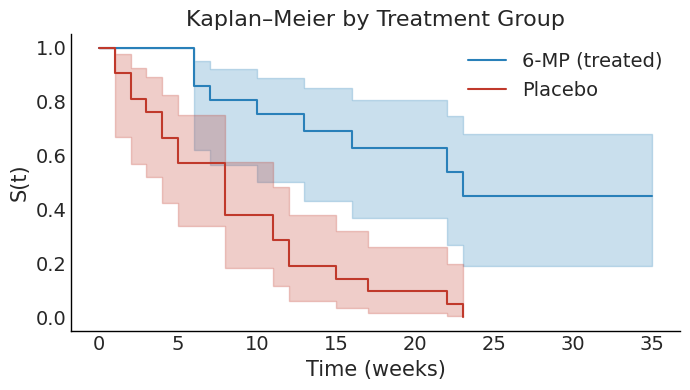

In [3]:
# Define arrays used throughout
X     = df[['sex', 'logWBC', 'Rx']].values
t     = df['t'].values
event = df['status'].values.astype(int)

print(df[['sex', 'logWBC', 'Rx', 't', 'status']].describe().round(3))

fig, ax = plt.subplots(figsize=(7, 4))
for rx, label, color in [(0, '6-MP (treated)', '#2980b9'), (1, 'Placebo', '#c0392b')]:
    kmf = KaplanMeierFitter()
    mask = df['Rx'] == rx
    kmf.fit(df.loc[mask, 't'], df.loc[mask, 'status'], label=label)
    kmf.plot_survival_function(ax=ax, color=color, ci_show=True)
ax.set_xlabel('Time (weeks)')
ax.set_ylabel('S(t)')
ax.set_title('Kaplan–Meier by Treatment Group')
ax.legend()
plt.tight_layout()
plt.show()

## 2. Key Design Decisions for Bayesian Cox PH with Poisson

Fitting a Cox PH model in a Bayesian framework requires several deliberate choices that do not arise in the classical frequentist setting. This section motivates each decision.

### 2.1  Why the Poisson Likelihood?

The classical Cox model is fit via the **partial likelihood**, which cancels out the unknown baseline hazard $h_0(t)$ analytically. This is elegant for MLE but is **not directly available in PyMC**: to build an MCMC sampler, PyMC requires a fully specified joint likelihood over *all* parameters — including $h_0(t)$.

The solution is the **Poisson–Exponential equivalence**. If we:
1. Discretise time into $K$ intervals $[c_0, c_1),\, [c_1, c_2),\, \ldots,\, [c_{K-1}, \infty)$, and
2. Treat the hazard as **piecewise constant** within each interval (piecewise exponential model),

then the event count in interval $k$ for observation $i$ is Poisson-distributed:

$$d_{ik} \sim \text{Poisson}\!\left(\lambda_{ik}\right), \qquad \lambda_{ik} = h_k \cdot \exp\!\bigl(x_i^\top \beta\bigr) \cdot e_{ik}$$

where $d_{ik} \in \{0,1\}$ is the binary event indicator, $h_k = e^{\ell_k}$ is the baseline hazard in interval $k$, and $e_{ik}$ is the **exposure** — the time observation $i$ is at risk within interval $k$.

Taking logs gives a standard **Poisson GLM with offset**:
$$\log \lambda_{ik} = \underbrace{\ell_k}_{\text{log-baseline}} + \underbrace{x_i^\top \beta}_{\text{log hazard ratio}} + \underbrace{\log e_{ik}}_{\text{offset}}$$

PyMC handles this natively with `pm.Poisson`, making the full joint posterior tractable.

> **Why not partial likelihood?**  Cox's partial likelihood is not a proper joint density for $(\beta, h_0)$ — it marginalises over $h_0$ analytically. PyMC's gradient-based NUTS sampler requires a complete log-joint, which the Poisson formulation provides.

### 2.2  Long-format Data Expansion

To evaluate the Poisson likelihood, each observation must be **split into one row per interval it is at risk**. This is the *person-period* (or counting-process) format.

For observation $i$ with time $t_i$ and event indicator $\delta_i$, given boundaries $[0, c_1, c_2, \ldots, \infty)$:

| Interval $[c_{k-1}, c_k)$ | At risk? | Exposure $e_{ik}$ | Event $d_{ik}$ |
|---|---|---|---|
| $[0, c_1)$ | $t_i > 0$ | $\min(t_i, c_1)$ | 0 |
| $[c_1, c_2)$ | $t_i > c_1$ | $\min(t_i, c_2) - c_1$ | 0 |
| $[c_{j}, t_i]$ (last interval) | $t_i > c_j$ | $t_i - c_j$ | $\delta_i$ |
| later intervals | $t_i \leq c_j$ | — | *not included* |

The expansion below shows 5 concrete observations with 3 intervals (cuts at the 33rd and 66th percentile of event times).

In [4]:
# Demonstrate long-format expansion on 5 observations
demo_cuts = np.quantile(t[event == 1], [1/3, 2/3])
boundaries_demo = np.concatenate([[0.0], demo_cuts, [np.inf]])
print(f'Cut points (3 intervals): {demo_cuts.round(2)}')

rows = []
for i in range(5):
    for k in range(3):
        left, right = boundaries_demo[k], boundaries_demo[k + 1]
        if t[i] <= left:
            break
        exposure = float(min(t[i], right) - left)
        ev_ik = int(event[i] == 1 and t[i] <= right)
        rows.append({
            'obs_id':     i,
            't_orig':     t[i],
            'event_orig': event[i],
            'interval k': k,
            f'[{left:.1f}, {right:.1f})': '',
            'exposure':   round(exposure, 2),
            'event_ik':   ev_ik,
        })

pd.DataFrame(rows)[['obs_id', 't_orig', 'event_orig', 'interval k', 'exposure', 'event_ik']]

Cut points (3 intervals): [ 6.   11.33]


,obs_id,t_orig,event_orig,interval k,exposure,event_ik
0,0,35,0,0,6.00,0
1,0,35,0,1,5.33,0
2,0,35,0,2,23.67,0
3,1,34,0,0,6.00,0
4,1,34,0,1,5.33,0
5,1,34,0,2,22.67,0
6,2,32,0,0,6.00,0
7,2,32,0,1,5.33,0
8,2,32,0,2,20.67,0
9,3,32,0,0,6.00,0


### 2.3  Gaussian Random Walk Prior on $\log h_0(t)$

We need a prior on the $K$-dimensional log-baseline vector $\ell = (\ell_1, \ldots, \ell_K)$.

**Why not independent Normal priors?**  Adjacent intervals share information — biologically, a hazard rate that spikes wildly between neighbouring intervals is implausible. Independent priors impose no smoothness, leading to high posterior variance and slow mixing.

**Gaussian Random Walk (GRW)**: each step is normally distributed around the previous value:
$$\ell_1 \sim \mathcal{N}(0, 1), \qquad \ell_k \mid \ell_{k-1} \sim \mathcal{N}(\ell_{k-1},\; \sigma_\ell^2), \quad k > 1$$

This acts as a **first-order smoothness prior**: the hazard drifts gradually, but large jumps are penalised. The step-size $\sigma_\ell \sim \text{HalfNormal}(1)$ is itself inferred from data, so the model learns how smooth the baseline should be — a flexible but regularised representation.

The plot below shows sample paths from this prior for two values of $\sigma_\ell$.

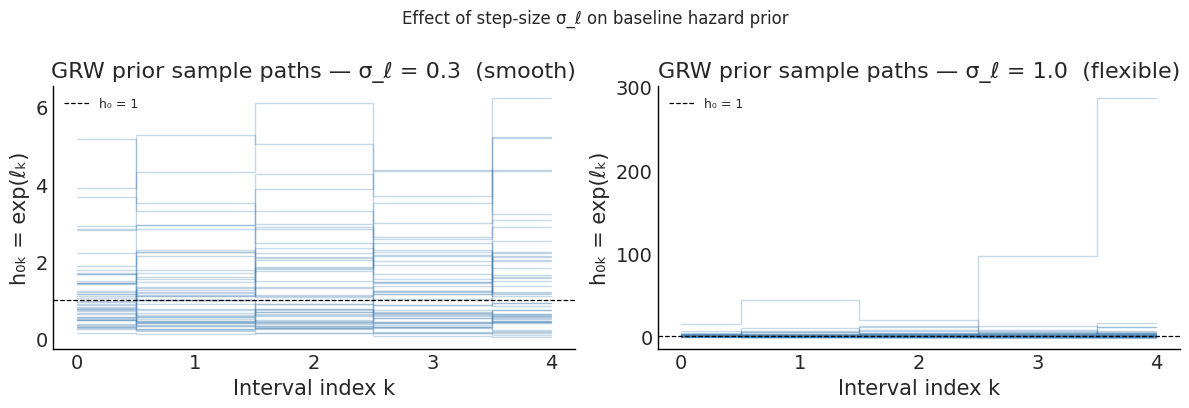

In [5]:
rng_vis = np.random.default_rng(0)
K_vis, n_paths = 5, 50

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, sigma, title in zip(axes,
                             [0.3, 1.0],
                             ['σ_ℓ = 0.3  (smooth)', 'σ_ℓ = 1.0  (flexible)']):
    for _ in range(n_paths):
        ell = np.zeros(K_vis)
        ell[0] = rng_vis.normal(0, 1)
        for j in range(1, K_vis):
            ell[j] = ell[j-1] + rng_vis.normal(0, sigma)
        ax.step(range(K_vis), np.exp(ell), where='mid', alpha=0.3, color='steelblue', lw=1)
    ax.axhline(1.0, color='black', lw=0.9, ls='--', label='h₀ = 1')
    ax.set_xlabel('Interval index k')
    ax.set_ylabel('h₀ₖ = exp(ℓₖ)')
    ax.set_title(f'GRW prior sample paths — {title}')
    ax.legend(fontsize=9)

plt.suptitle('Effect of step-size σ_ℓ on baseline hazard prior', y=1.01)
plt.tight_layout()
plt.show()

### 2.4  Choosing Interval Boundaries

The cut points define the temporal resolution of the baseline hazard. Two strategies are supported:

| Strategy | Argument | Rule | When to prefer |
|---|---|---|---|
| Quantile-based | `n_intervals=K` | Interior cuts at $K-1$ evenly-spaced quantiles of **event times** | Default; ensures each interval contains ≈ the same number of events |
| Fixed cuts | `cuts=[c₁, c₂, …]` | User-specified boundaries | When domain knowledge dictates clinically meaningful thresholds |

**Why event times only?**  Quantiles are computed on uncensored observations so events are spread evenly across intervals. If we used all times, censored-heavy intervals would have sparse events and poorly identified $h_{0k}$.

**Sensitivity to $K$**: more intervals give a finer baseline at the cost of higher variance. With a GRW prior the smoothness is data-adaptive, so the model is less sensitive to this choice than with independent priors. As a rule of thumb, $K \in [4, 10]$ works well for datasets of 30–500 events.

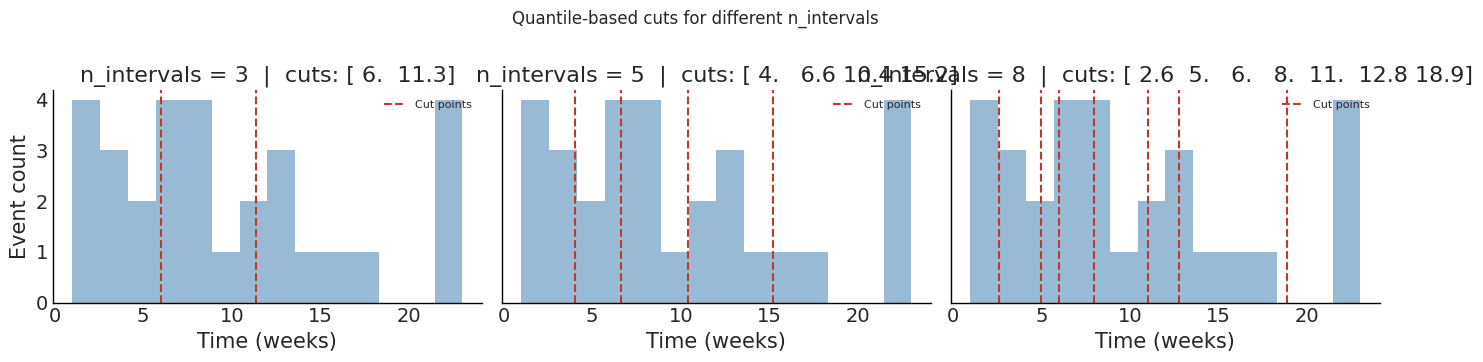


n_intervals = 5  →  cuts = [ 4.   6.6 10.4 15.2]


In [6]:
event_times = t[event == 1]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=True)
for ax, n_int in zip(axes, [3, 5, 8]):
    q = np.linspace(0, 1, n_int + 1)[1:-1]
    cuts_k = np.unique(np.quantile(event_times, q))
    ax.hist(event_times, bins=14, color='steelblue', alpha=0.55)
    for i, c in enumerate(cuts_k):
        ax.axvline(c, color='#c0392b', lw=1.5, ls='--',
                   label='Cut points' if i == 0 else '')
    ax.set_title(f'n_intervals = {n_int}  |  cuts: {cuts_k.round(1)}')
    ax.set_xlabel('Time (weeks)')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Event count')
plt.suptitle('Quantile-based cuts for different n_intervals', y=1.02)
plt.tight_layout()
plt.show()

# We will use n_intervals = 5
n_intervals = 5
cuts5 = np.unique(np.quantile(event_times, np.linspace(0, 1, n_intervals + 1)[1:-1]))
print(f'\nn_intervals = 5  →  cuts = {cuts5}')

### 2.5  Identifiability: No Intercept in $\beta$

The standard Cox PH model has **no intercept in the regression coefficients** $\beta$. In our formulation, an intercept would be **non-identifiable**: adding a constant $c$ to every $\beta$ is indistinguishable from subtracting $c$ from every $\ell_k$, because:
$$\ell_k + (x^\top\beta + c) \;=\; (\ell_k + c) + x^\top\beta$$

The model resolves this by:
- Letting the GRW log-baseline $\ell_k$ absorb the overall hazard level (playing the role of an intercept).
- Restricting $\beta$ to **covariate effects only** — each $\beta_j$ is a log hazard ratio relative to baseline.

Consequently, `_augment_X()` from the base class is deliberately *not* called in `PiecewiseCoxPHModel.build_model()`.

> **Sign convention note**: Cox PH $\beta_j > 0$ means *more* hazard → *shorter* survival. This is the **opposite** of AFT models, where $\beta_j > 0$ means *decelerated* failure time → *longer* survival.

## 3. Frequentist Baseline: `lifelines.CoxPHFitter`

`lifelines.CoxPHFitter` maximises Cox's partial likelihood. The baseline hazard $h_0(t)$ is not estimated during fitting; it is recovered post-hoc via the **Breslow estimator** when survival predictions are required.

Coefficients are reported as log hazard ratios ($\hat{\beta}$) with asymptotic 95% confidence intervals.

In [7]:
cph = CoxPHFitter()
cph.fit(df, duration_col='t', event_col='status')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 42 total observations, 12 right-censored observations>
             duration col = 't'
                event col = 'status'
      baseline estimation = breslow
   number of observations = 42
number of events observed = 30
   partial log-likelihood = -69.59
         time fit was run = 2026-04-05 05:45:55 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
sex        0.31      1.37      0.45           -0.58            1.21                0.56                3.34
logWBC     1.68      5.38      0.34            1.02            2.34                2.78               10.40
Rx         1.50      4.50      0.46            0.60            2.41                1.82               11.11

           cmp to    z      p  -log2(p)
covariate                              
sex          0.00 0.69   0.49      1.03
logWBC       0.00 5.00 <0.005     20.71
Rx           0.00 3.26 <0.005      9.80
---
Concordance = 0.85
Partial AIC = 145.18
log-likelihood ratio test = 47.19 on 3 df
-log2(p) of ll-ratio test = 31.55

## 4. Bayesian Piecewise Cox PH Model

We fit `PiecewiseCoxPHModel` with `n_intervals=5`, letting the model place cut points at event-time quantiles.

Default priors:

| Parameter | Prior | Role |
|---|---|---|
| $\sigma_\ell$ | $\text{HalfNormal}(1)$ | GRW step size — controls baseline smoothness |
| $\ell_k$ | $\text{GaussianRandomWalk}(\sigma_\ell),\; k=1,\ldots,K$ | Log piecewise constant baseline hazard |
| $\beta_j$ | $\mathcal{N}(0, 1),\; j=1,\ldots,p$ | Log hazard ratio per covariate (no intercept) |

In [24]:
bayes_model = PiecewiseCoxPHModel(n_intervals=20)

bayes_model.fit(
    X,
    t,
    event,
    draws=1000,
    tune=1000,
    chains=4,
    target_accept=0.99,
    random_seed=42,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [grw_sigma, log_baseline, beta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 43 seconds.
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [25]:
az.summary(bayes_model.idata, var_names=['log_baseline', 'beta', 'grw_sigma'], hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
log_baseline[0],-8.852,1.384,-11.655,-6.266,0.069,0.049,402.0,722.0,1.01
log_baseline[1],-8.584,1.298,-11.145,-6.109,0.064,0.046,408.0,735.0,1.01
log_baseline[2],-8.497,1.253,-11.093,-6.197,0.062,0.044,407.0,696.0,1.01
log_baseline[3],-8.146,1.172,-10.439,-5.851,0.057,0.041,419.0,741.0,1.01
log_baseline[4],-7.964,1.118,-10.207,-5.827,0.054,0.038,423.0,736.0,1.01
log_baseline[5],-7.815,1.118,-9.968,-5.659,0.054,0.038,430.0,703.0,1.01
log_baseline[6],-7.333,1.047,-9.394,-5.335,0.048,0.034,470.0,712.0,1.01
log_baseline[7],-7.433,1.046,-9.604,-5.525,0.050,0.035,437.0,759.0,1.01
log_baseline[8],-7.187,0.970,-9.223,-5.502,0.046,0.033,442.0,777.0,1.01
log_baseline[9],-7.334,0.987,-9.283,-5.444,0.049,0.034,413.0,674.0,1.01


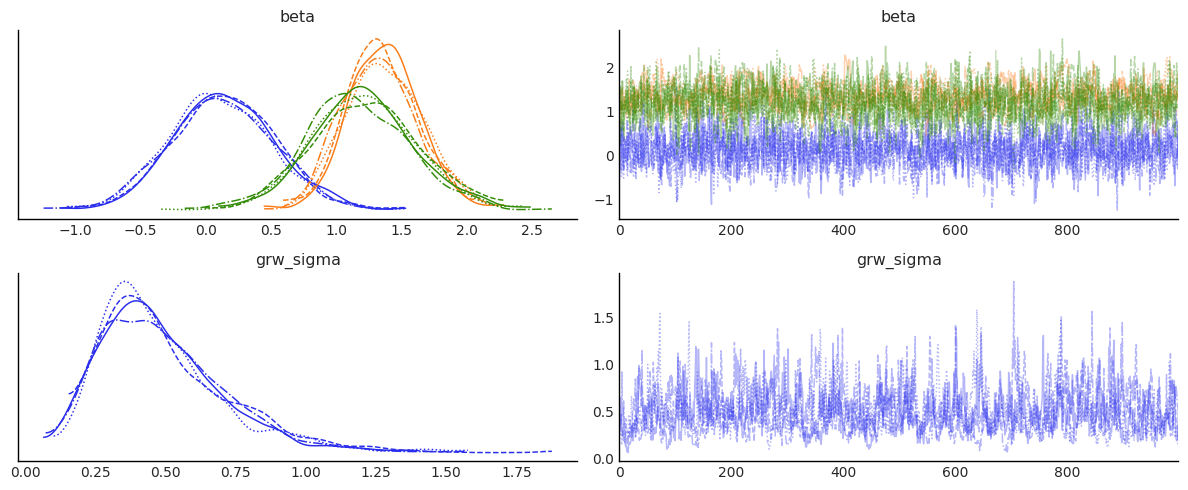

In [26]:
az.plot_trace(bayes_model.idata, var_names=['beta', 'grw_sigma'], compact=True, figsize=(12, 5))
plt.tight_layout()
plt.show()

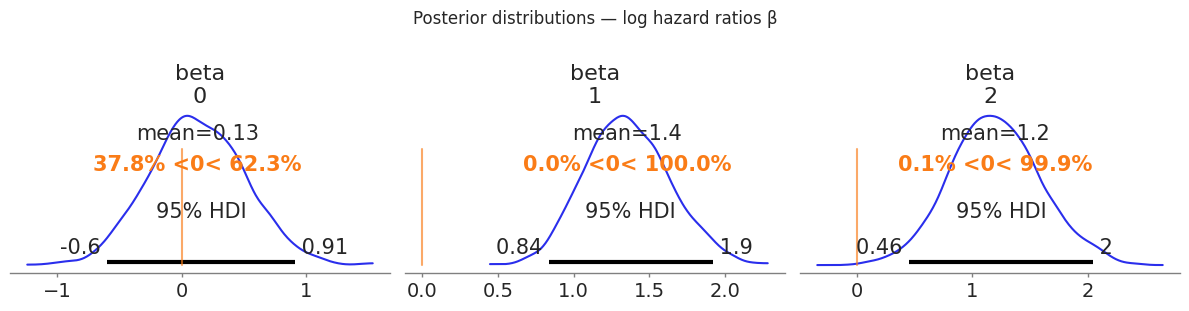

In [27]:
az.plot_posterior(
    bayes_model.idata,
    var_names=['beta'],
    hdi_prob=0.95,
    ref_val=0,
    figsize=(12, 3),
)
plt.suptitle('Posterior distributions — log hazard ratios β', y=1.02)
plt.tight_layout()
plt.show()

## 5. Coefficient Comparison

Both models estimate **log hazard ratios** with the same sign convention: $\beta_j > 0$ means higher hazard. We compare:
- `lifelines`: point estimate + asymptotic 95% CI
- Bayesian: posterior mean + 95% HDI

In [28]:
feature_names = ['sex', 'logWBC', 'Rx']

# lifelines
ll_coef = cph.params_[feature_names].values
ci_cols  = cph.confidence_intervals_.columns.tolist()
ll_lo    = cph.confidence_intervals_.loc[feature_names, ci_cols[0]].values
ll_hi    = cph.confidence_intervals_.loc[feature_names, ci_cols[1]].values

# Bayesian
summary    = az.summary(bayes_model.idata, var_names=['beta'], hdi_prob=0.95)
hdi_cols   = [c for c in summary.columns if 'hdi' in c.lower()]
bayes_mean = summary['mean'].values
bayes_lo   = summary[hdi_cols[0]].values
bayes_hi   = summary[hdi_cols[1]].values

comparison = pd.DataFrame({
    'Feature':          feature_names,
    'lifelines coef':   ll_coef.round(3),
    'lifelines 95% CI': [f'[{lo:.3f}, {hi:.3f}]' for lo, hi in zip(ll_lo, ll_hi)],
    'Bayes mean':       bayes_mean.round(3),
    'Bayes 95% HDI':    [f'[{lo:.3f}, {hi:.3f}]' for lo, hi in zip(bayes_lo, bayes_hi)],
})
comparison

,Feature,lifelines coef,lifelines 95% CI,Bayes mean,Bayes 95% HDI
0,sex,0.315,"[-0.576, 1.206]",0.127,"[-0.598, 0.912]"
1,logWBC,1.682,"[1.022, 2.342]",1.355,"[0.836, 1.918]"
2,Rx,1.504,"[0.599, 2.408]",1.200,"[0.456, 2.045]"


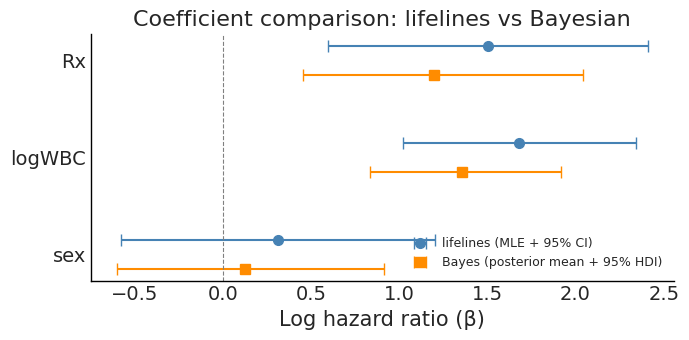

In [29]:
fig, ax = plt.subplots(figsize=(7, 3.5))
y = np.arange(len(feature_names))
offset = 0.15

ax.errorbar(
    ll_coef, y + offset,
    xerr=[ll_coef - ll_lo, ll_hi - ll_coef],
    fmt='o', color='steelblue', label='lifelines (MLE + 95% CI)',
    capsize=4, lw=1.5, ms=7,
)
ax.errorbar(
    bayes_mean, y - offset,
    xerr=[bayes_mean - bayes_lo, bayes_hi - bayes_mean],
    fmt='s', color='darkorange', label='Bayes (posterior mean + 95% HDI)',
    capsize=4, lw=1.5, ms=7,
)

ax.axvline(0, color='grey', lw=0.8, ls='--')
ax.set_yticks(y)
ax.set_yticklabels(feature_names)
ax.set_xlabel('Log hazard ratio (β)')
ax.set_title('Coefficient comparison: lifelines vs Bayesian')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## 6. Survival Function Comparison

We evaluate three representative patient profiles (same as the AFT notebook for cross-model comparison):

| Profile | logWBC | Rx | Expected |
|---|---|---|---|
| Treated, low WBC | 25th percentile | 0 (6-MP) | Best prognosis |
| Treated, high WBC | 75th percentile | 0 (6-MP) | Intermediate |
| Control, high WBC | 75th percentile | 1 (placebo) | Worst prognosis |

All profiles fix `sex = 1`. The lifelines prediction uses the Breslow baseline estimator; the Bayesian shaded region is the 95% HDI over posterior draws.

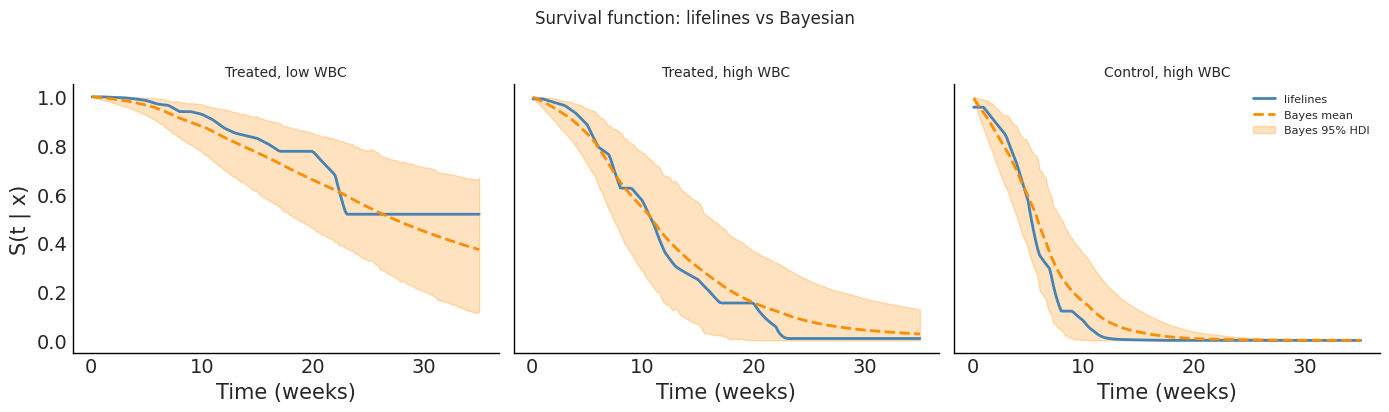

In [30]:
logwbc_lo = np.percentile(df['logWBC'], 25)
logwbc_hi = np.percentile(df['logWBC'], 75)

profiles_X = np.array([
    [1, logwbc_lo, 0],
    [1, logwbc_hi, 0],
    [1, logwbc_hi, 1],
])
profile_labels = ['Treated, low WBC', 'Treated, high WBC', 'Control, high WBC']
profiles_df = pd.DataFrame(profiles_X, columns=['sex', 'logWBC', 'Rx'])

eval_times = np.linspace(0.1, df['t'].max(), 200)

# lifelines survival (Breslow estimator)
ll_surv = cph.predict_survival_function(profiles_df, times=eval_times)

# Bayesian survival
bayes_pred = bayes_model.predict_survival_function(profiles_X, eval_times, hdi_prob=0.95)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for i, (ax, label) in enumerate(zip(axes, profile_labels)):
    ax.plot(eval_times, ll_surv.iloc[:, i], color='steelblue', lw=2, label='lifelines')
    ax.plot(eval_times, bayes_pred.mean[i], color='darkorange', lw=2, ls='--', label='Bayes mean')
    ax.fill_between(
        eval_times,
        bayes_pred.hdi_lower[i],
        bayes_pred.hdi_upper[i],
        color='darkorange', alpha=0.25, label='Bayes 95% HDI',
    )
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Time (weeks)')
    if i == 0:
        ax.set_ylabel('S(t | x)')
    if i == 2:
        ax.legend(fontsize=8, loc='upper right')

plt.suptitle('Survival function: lifelines vs Bayesian', y=1.02)
plt.tight_layout()
plt.show()

## 7. Estimated Baseline Hazard

A key advantage of the Bayesian model over standard Cox PH is that the baseline hazard $h_0(t)$ is **jointly estimated** with $\beta$ rather than recovered post-hoc.

- **Bayesian**: posterior distribution over $K$ piecewise constant rates $h_{0k} = e^{\ell_k}$. Plotted as posterior mean + 95% HDI step function.
- **lifelines (Breslow)**: non-parametric step function jumping at each unique event time. No uncertainty quantification.

**Reference level**: `lifelines` internally mean-centres covariates before fitting, so its `baseline_hazard_` is the hazard for a patient with covariate values equal to the **sample mean** (i.e. $\bar{X}$), not at the literal zero of each covariate. The Bayesian log-baseline $\ell_k$ is naturally at the all-zeros reference (here: `sex=0, logWBC=0, Rx=0`), which corresponds to an extremely low WBC count that is far outside the data range. To put both curves on the same scale we evaluate the Bayesian baseline at $\bar{X}$ by multiplying by $\exp(\hat{\beta}^\top \bar{x})$ for each posterior draw.

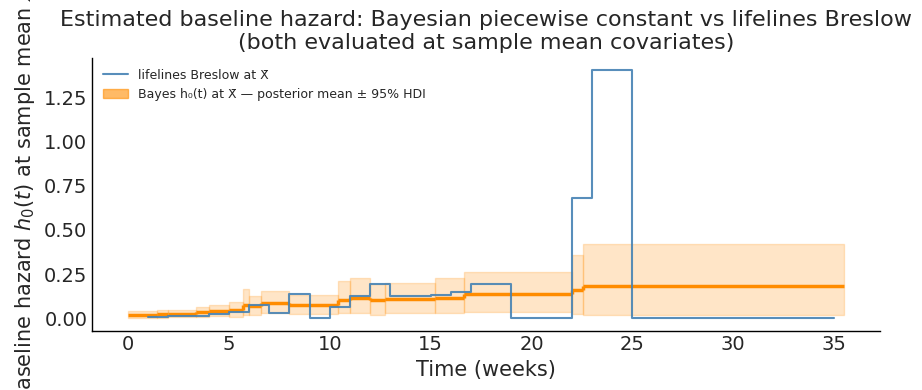

In [31]:
# Extract Bayesian posterior samples
lb_samples   = bayes_model.idata.posterior['log_baseline'].values  # (chains, draws, K)
beta_samples = bayes_model.idata.posterior['beta'].values           # (chains, draws, p)
n_chains, n_draws, K = lb_samples.shape
S = n_chains * n_draws

h0_samples = np.exp(lb_samples.reshape(S, K))  # (S, K)  — at literal X=0 reference
beta_flat  = beta_samples.reshape(S, -1)         # (S, p)

# lifelines internally mean-centres covariates, so baseline_hazard_ is at the
# sample mean of X, not at X=0.  Adjust the Bayesian baseline to the same
# reference by multiplying each sample by exp(beta @ X_mean).
X_mean     = X.mean(axis=0)                             # (p,)
hr_at_mean = np.exp(beta_flat @ X_mean)                 # (S,)
h0_ref     = h0_samples * hr_at_mean[:, np.newaxis]     # (S, K)  — at X_mean reference

h0_mean = h0_ref.mean(axis=0)                                                # (K,)
h0_hdi  = np.array([az.hdi(h0_ref[:, k], hdi_prob=0.95) for k in range(K)]) # (K, 2)

# Interval boundaries for plotting (cap last boundary at t_max for display)
t_max = df['t'].max()
boundaries = np.concatenate([[0.0], bayes_model._cuts, [t_max + 1]])
lefts  = boundaries[:-1]
rights = boundaries[1:]

# lifelines Breslow baseline hazard
ll_bh = cph.baseline_hazard_

fig, ax = plt.subplots(figsize=(9, 4))

# Bayesian: step function per interval
for k in range(K):
    r = min(rights[k], t_max + 0.5)
    ax.hlines(h0_mean[k], lefts[k], r, color='darkorange', lw=2.5)
    ax.fill_between([lefts[k], r], h0_hdi[k, 0], h0_hdi[k, 1], color='darkorange', alpha=0.22)
# Add vertical connectors for a proper step appearance
for k in range(K - 1):
    ax.vlines(rights[k], h0_mean[k], h0_mean[k+1], color='darkorange', lw=2.5)

bayes_handle = mpatches.Patch(color='darkorange', alpha=0.6,
                               label='Bayes h₀(t) at X̄ — posterior mean ± 95% HDI')

# lifelines: step function at each event time
ax.step(ll_bh.index, ll_bh['baseline hazard'].values,
        where='post', color='steelblue', lw=1.5, alpha=0.9, label='lifelines Breslow at X̄')

ax.set_xlabel('Time (weeks)')
ax.set_ylabel('Baseline hazard $h_0(t)$ at sample mean $\\bar{X}$')
ax.set_title('Estimated baseline hazard: Bayesian piecewise constant vs lifelines Breslow\n(both evaluated at sample mean covariates)')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + [bayes_handle], fontsize=9)
plt.tight_layout()
plt.show()

## Summary

| Aspect | `lifelines.CoxPHFitter` | `bayes_survival.PiecewiseCoxPHModel` |
|---|---|---|
| Likelihood | Cox partial likelihood | Poisson (long-format expansion) |
| Baseline hazard | Breslow (post-hoc, no uncertainty) | Piecewise constant, jointly inferred |
| Coefficients | Point estimates + asymptotic 95% CI | Full posterior + 95% HDI |
| Baseline prior | None | GRW on log-baseline; HalfNormal step size |
| Baseline smoothness | Non-parametric step at each event time | GRW-regularised; adapts to data |
| Compute | Seconds (MLE) | Minutes (MCMC) |
| Prediction | Single survival curve | Posterior envelope |

### Key observations

1. **Coefficient recovery**: Both models recover nearly identical log hazard ratio estimates. `Rx` has a large positive coefficient (placebo → higher hazard); `logWBC` is also strongly positive (high WBC → poor prognosis). Both are statistically clear.

2. **Sign convention**: Cox PH $\beta_j > 0$ means *more* hazard — the opposite of AFT where $\beta_j > 0$ means *longer* survival. Always read Cox PH coefficients as hazard ratios, not time ratios.

3. **Baseline hazard reference levels**: `lifelines` internally mean-centres covariates, so `baseline_hazard_` is the hazard for the *average* patient. The Bayesian log-baseline $\ell_k$ is at the all-zeros covariate vector (here `logWBC=0`, a WBC count of 1 — far outside the data range), which yields a baseline hazard several orders of magnitude smaller than the Breslow estimate. The section-7 plot corrects for this by shifting both curves to the sample-mean reference via $h_0(t)\,\exp(\hat{\beta}^\top\bar{x})$.

4. **Uncertainty propagation**: Bayesian HDI envelopes widen in the tail where data are sparse — the model correctly propagates uncertainty about both $\beta$ *and* $h_0(t)$ into predictions. lifelines uncertainty comes from $\hat{\beta}$ only; baseline uncertainty is ignored.

5. **The Poisson trick**: The long-format expansion is the key computational step that makes full Bayesian Cox PH tractable in PyMC. The GRW baseline and `pm.Poisson` likelihood together replace the partial likelihood, enabling joint MCMC inference over all parameters.